### Imports

In [146]:
import io
from io import BytesIO
import fitz
import os
import base64
from typing import List, Tuple
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy.ndimage import gaussian_filter1d
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

from pdf2image import convert_from_path
from tabulate import tabulate

import textwrap

### Paths

In [147]:
test_sample_1 = "/home/jerlshin/FieldOfInterest/My_Work/__PROJECTS__/TableExtraction/page_1.pdf"
test_sample_2 = "/home/jerlshin/FieldOfInterest/My_Work/__PROJECTS__/TableExtraction/page_2.pdf"

### Pipeline


Here's a breakdown of the steps involved in reconstructing tables from document images:

**1. Preprocess & Filter Text Elements**

* Use font size, weight (**bold**), and styling to remove table titles/captions.
* Retain only column headers and cell content.

**2. Map Bounding Boxes to 2D Space**

* Represent all text blocks as rectangles on an X-Y coordinate plane.

**3. Detect Column Boundaries (X-Axis)**

* Generate a word density histogram along the x-axis.
* Apply smoothing to suppress noise.
* Identify valleys (low-density regions) as vertical separators between columns.

**4. Detect Row Boundaries (Y-Axis)**

* Similarly, compute a density plot along the y-axis to find horizontal separators (rows).

**5. Construct Grid from Intersections**

* Use x and y separators to build a virtual table grid.
* Assign each text box to its corresponding cell based on its coordinates.

**6. Reconstruct Table**

* Extract content cell-wise from the grid.
* Identify column headers using heuristics (position, font).
* Output the reconstructed table with correct structure and content.

---

## **1.** Preprocessing

In [150]:
# Opening PDF
doc = fitz.open(test_sample_2)

page = doc[0]

In [151]:

page_width = page.rect.width
page_height = page.rect.height

print("Page Width:", page_width)
print("Page Height:", page_height)


Page Width: 486.0
Page Height: 270.0


* Filtering small blocks
* Extracting font metadata
* Creating a unified text representation
* Structuring it into a DataFrame

In [152]:
word_data = []
area_threshold = 130  # block level

for block in page.get_text("dict")["blocks"]:
    # block area
    x0, y0, x1, y1 = block.get("bbox", (0, 0, 0, 0))
    width = x1 - x0
    height = y1 - y0
    area = width * height

    # Skiping blocks below area threshold
    if area < area_threshold:
        continue

    # Process words only in valid blocks
    for line in block.get("lines", []):
        for span in line.get("spans", []):
            font_size = span["size"]
            font_name = span["font"]
            is_bold = "Bold" in font_name

            span_bbox = span["bbox"]
            span_width = span_bbox[2] - span_bbox[0]
            span_height = span_bbox[3] - span_bbox[1]

            words = span.get("text").split()
            num_words = len(words)

            # Skip empty or broken spans
            if num_words == 0:
                continue

            word_width = span_width / num_words  # simple estimate

            for idx, word in enumerate(words):
                word_x0 = span_bbox[0] + idx * word_width
                word_x1 = word_x0 + word_width
                y0 = span_bbox[1]
                y1 = span_bbox[3]
                word_area = word_width * span_height

                word_data.append({
                    "text": word,
                    "font_size": font_size,
                    "font_name": font_name,
                    "is_bold": is_bold,
                    "bbox": (word_x0, y0, word_x1, y1),
                    "y_position": y0,
                    "width": word_width,
                    "height": span_height,
                    "area": word_area
                })

df_words = pd.DataFrame(word_data)
df_words = df_words.sort_values(by="y_position").reset_index(drop=True)

df_words.head()

,text,font_size,font_name,is_bold,bbox,y_position,width,height,area
0,Bariod,10.0,Arial.Bold083.313,True,"(192.68702697753906, 13.898979187011719, 226.1...",13.898979,33.465897,10.0,334.658966
1,Fluids,10.0,Arial.Bold083.313,True,"(226.15292358398438, 13.898979187011719, 259.6...",13.898979,33.465897,10.0,334.658966
2,Listing,10.0,Arial.Bold083.313,True,"(259.6188201904297, 13.898979187011719, 293.08...",13.898979,33.465897,10.0,334.658966
3,systems,6.5,Arial.Bold054.188,True,"(314.90114974975586, 32.81417465209961, 340.57...",32.814175,25.673710,6.5,166.879114
4,Recommended,6.5,Arial.Bold054.188,True,"(237.88002014160156, 32.81417465209961, 263.55...",32.814175,25.673710,6.5,166.879114


In [153]:
len(df_words)

194

* Eliminating Extraneous Headers

In [154]:
def remove_table_header(df):

    # 1. Find the topmost y-position
    if df.empty:
        return df

    top_y = df['y_position'].min()

    # 2. Select words with the topmost y-position
    top_row_words = df[df['y_position'] == top_y]

    # 3. Identify bold words in the top row
    bold_header_words = top_row_words[df['is_bold'] == True] # changed df to df['is_bold']

    # 4. Get indices of bold header words
    header_indices = bold_header_words.index

    # 5. Remove the header words from the original DataFrame
    df_no_header = df.drop(header_indices).reset_index(drop=True)

    return df_no_header


df_words = remove_table_header(df_words.copy())

df_words.head()


/tmp/ipykernel_285929/2134171721.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bold_header_words = top_row_words[df['is_bold'] == True] # changed df to df['is_bold']


,text,font_size,font_name,is_bold,bbox,y_position,width,height,area
0,systems,6.5,Arial.Bold054.188,True,"(314.90114974975586, 32.81417465209961, 340.57...",32.814175,25.673710,6.5,166.879114
1,Recommended,6.5,Arial.Bold054.188,True,"(237.88002014160156, 32.81417465209961, 263.55...",32.814175,25.673710,6.5,166.879114
2,these,6.5,Arial.Bold054.188,True,"(289.2274398803711, 32.81417465209961, 314.901...",32.814175,25.673710,6.5,166.879114
3,for,6.5,Arial.Bold054.188,True,"(263.5537300109863, 32.81417465209961, 289.227...",32.814175,25.673710,6.5,166.879114
4,Product,6.5,Arial.Bold054.188,True,"(423.601318359375, 32.81417465209961, 448.1440...",32.814175,24.542755,6.5,159.527908


## **2.** Map Bounding

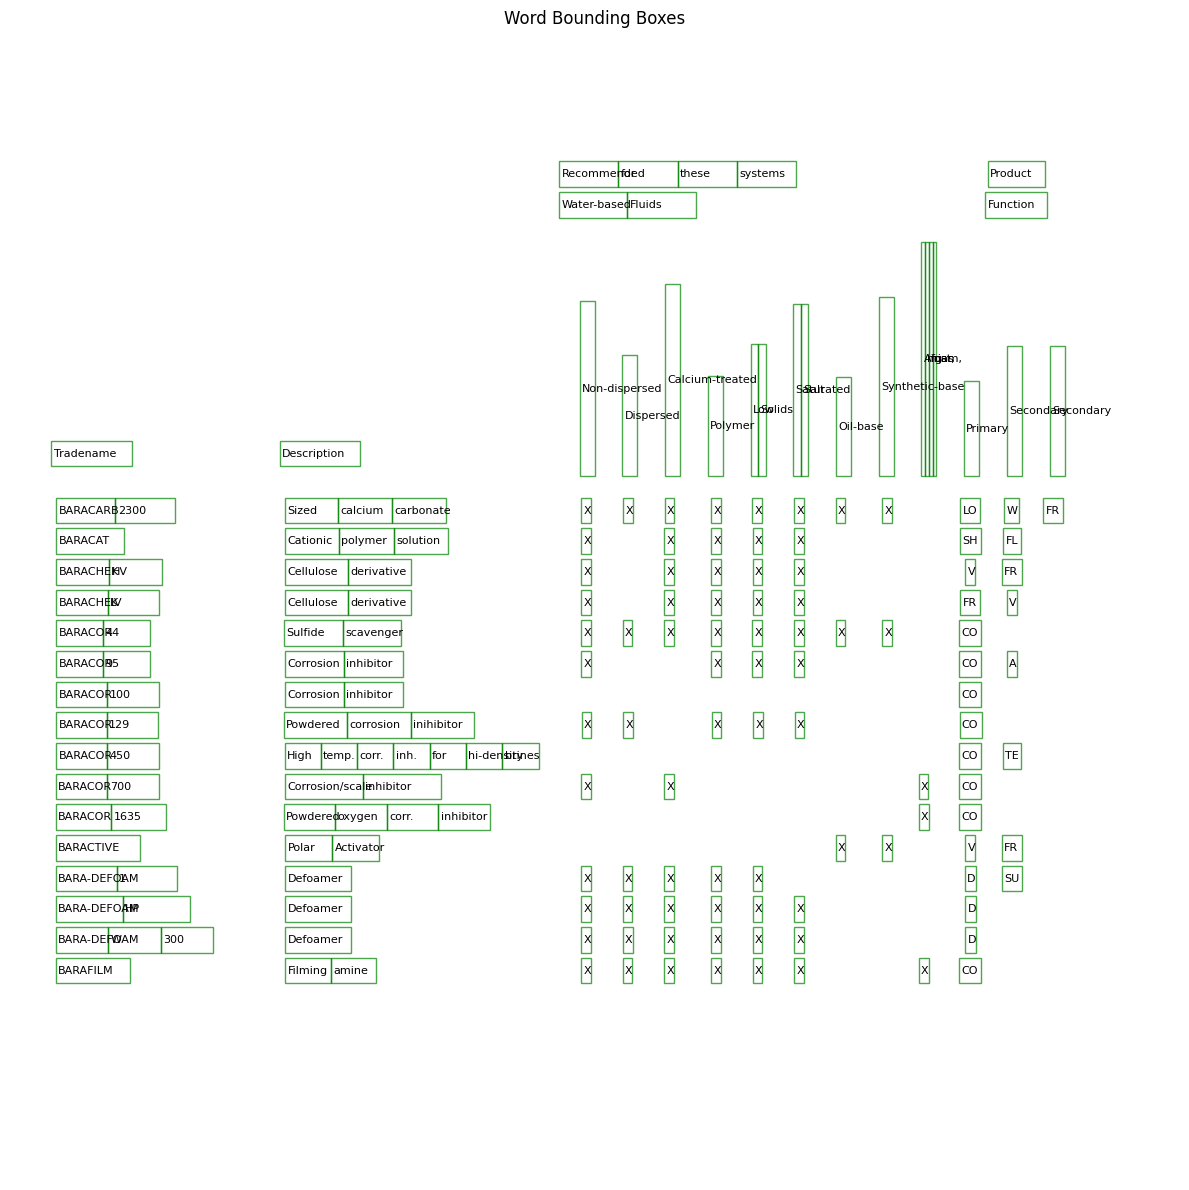

In [155]:

def plot_word_bounding_boxes(df, figsize=(12, 12), max_chars_per_line=20):

    fig, ax = plt.subplots(figsize=figsize)
    # Ensure the x and y limits are set correctly based on word coordinates
    x_max = df['bbox'].apply(lambda b: b[2]).max() if not df.empty else 0
    y_max = df['bbox'].apply(lambda b: b[3]).max() if not df.empty else 0

    ax.set_xlim(0, x_max + 50)
    ax.set_ylim(y_max + 50, 0)  # Invert Y axis

    for _, row in df.iterrows():
        x0, y0, x1, y1 = row['bbox']
        width = x1 - x0
        height = y1 - y0
        rect = patches.Rectangle(
            (x0, y0), width, height,
            linewidth=1, edgecolor='green', facecolor='none', alpha=0.7)  # Changed color to green
        ax.add_patch(rect)
        ax.text(x0 + 1, y0 + height / 2, row['text'], fontsize=8, verticalalignment='center') #increased fontsize

    ax.set_title("Word Bounding Boxes")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_word_bounding_boxes(df_words)

### Sentence Construction

In [156]:

def merge_line(line_words):
    if len(line_words) == 1:
        row = line_words[0]
        return {
            "text": row['text'],
            "font_size": row['font_size'],
            "font_name": row['font_name'],
            "is_bold": row['is_bold'],
            "bbox": row['bbox'],
            "y_position": row['bbox'][1]
        }

    texts = [w['text'] for w in line_words]
    font_sizes = [w['font_size'] for w in line_words]
    font_names = [w['font_name'] for w in line_words]
    is_bold_flags = [w['is_bold'] for w in line_words]

    x0 = min(w['bbox'][0] for w in line_words)
    y0 = min(w['bbox'][1] for w in line_words)
    x1 = max(w['bbox'][2] for w in line_words)
    y1 = max(w['bbox'][3] for w in line_words)

    return {
        "text": " ".join(texts),
        "font_size": sum(font_sizes) / len(font_sizes),
        "font_name": max(set(font_names), key=font_names.count),
        "is_bold": any(is_bold_flags),
        "bbox": (x0, y0, x1, y1),
        "y_position": y0
    }


In [157]:
def merge_adjacent_words(df_words, x_threshold=5, y_threshold=2):
    merged_rows = []

    # Step 1: Sort by y_position (top-down), then x (left-right)
    df_sorted = df_words.copy()
    df_sorted['x0'] = df_sorted['bbox'].apply(lambda b: b[0])
    df_sorted['y0'] = df_sorted['bbox'].apply(lambda b: b[1])
    df_sorted = df_sorted.sort_values(by=['y0', 'x0']).reset_index(drop=True)

    current_line = []
    prev_y = None

    for idx, row in df_sorted.iterrows():
        x0, y0, x1, y1 = row['bbox']
        text = row['text']

        if not current_line:
            current_line.append(row)
            prev_y = y0
            continue

        # Same line if vertical difference is small
        if abs(y0 - prev_y) <= y_threshold:
            prev_word = current_line[-1]
            prev_x1 = prev_word['bbox'][2]
            
            # Check horizontal proximity
            if x0 - prev_x1 <= x_threshold:
                current_line.append(row)
                continue

        # Otherwise, finish current line and start new
        if current_line:
            merged_rows.append(merge_line(current_line))
        current_line = [row]
        prev_y = y0

    # Add the last line
    if current_line:
        merged_rows.append(merge_line(current_line))

    return pd.DataFrame(merged_rows)


In [158]:
df_sentences = merge_adjacent_words(df_words)


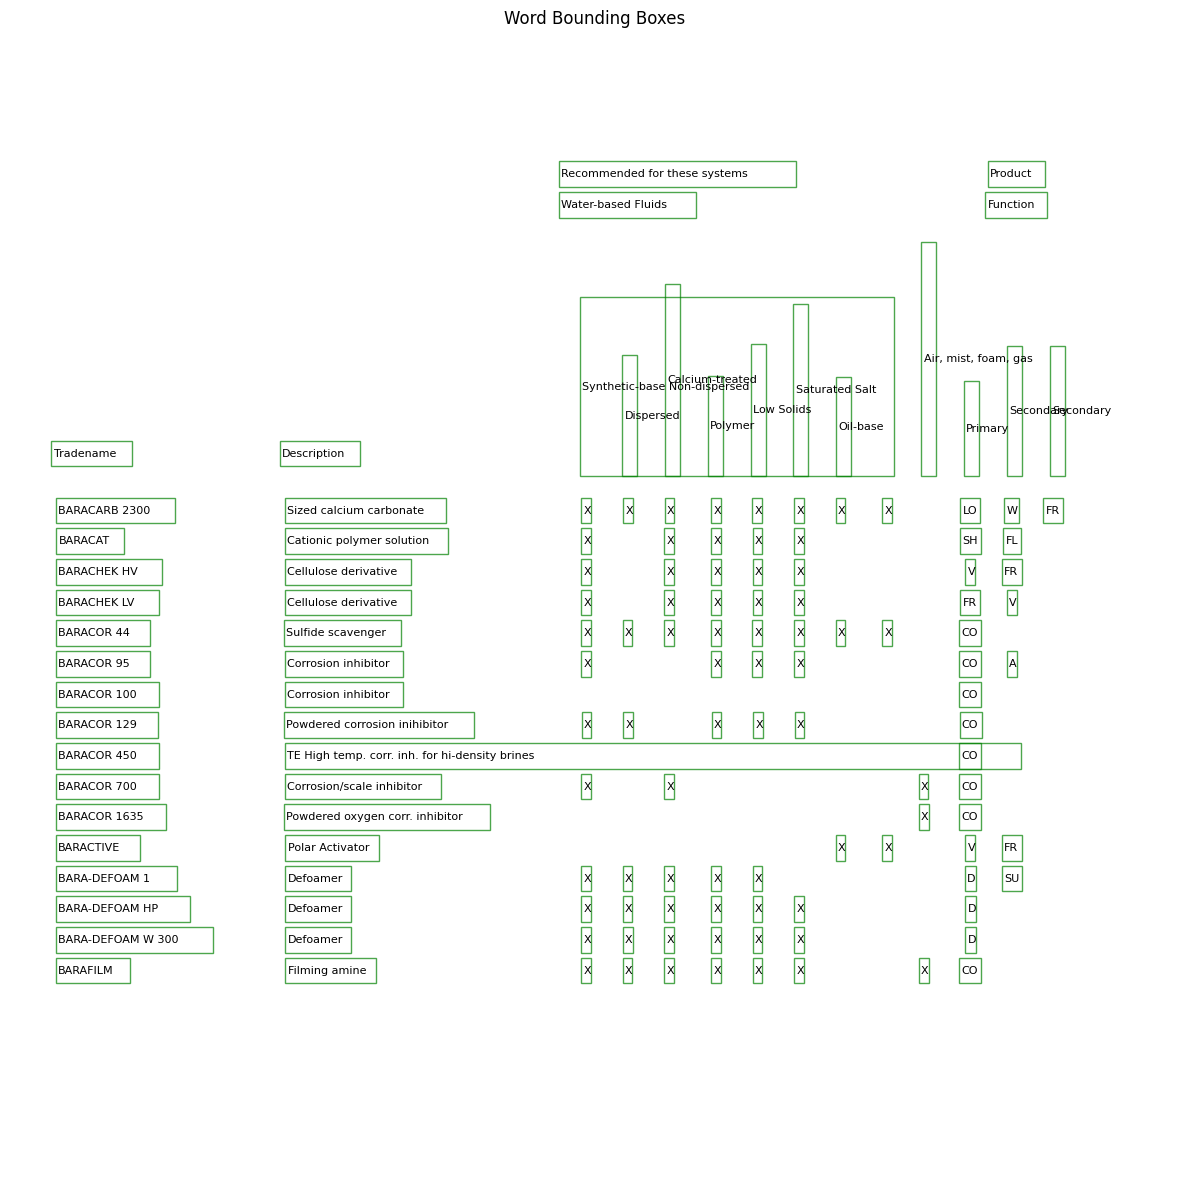

In [159]:
plot_word_bounding_boxes(df_sentences)

## **3.** Density Distribution


* It treats page like a spatial histogram
  * X-axis density (for columns)
  * Y-axis density (for rows)
  * Smoothing

In [160]:
def compute_density_along_axis(df_words, axis='x', bin_size=2, smooth_sigma=2, plot=True):
    assert axis in ['x', 'y'], "Axis must be 'x' or 'y'"

    # Determine span along chosen axis
    if axis == 'x':
        min_val = df_words['bbox'].apply(lambda b: b[0]).min()
        max_val = df_words['bbox'].apply(lambda b: b[2]).max()
    else:
        min_val = df_words['bbox'].apply(lambda b: b[1]).min()
        max_val = df_words['bbox'].apply(lambda b: b[3]).max()

    bins = np.arange(min_val, max_val + bin_size, bin_size)
    density = np.zeros(len(bins))

    for _, row in df_words.iterrows():
        x0, y0, x1, y1 = row['bbox']

        if axis == 'x':
            start_bin = int((x0 - min_val) // bin_size)
            end_bin = int((x1 - min_val) // bin_size)
        else:
            start_bin = int((y0 - min_val) // bin_size)
            end_bin = int((y1 - min_val) // bin_size)

        density[start_bin:end_bin + 1] += 1

    # Smooth the density curve
    smoothed_density = gaussian_filter1d(density, sigma=smooth_sigma)

    if plot:
        plt.figure(figsize=(12, 4))
        plt.plot(bins, smoothed_density, label=f"{axis.upper()}-axis word density", color='darkgreen')
        plt.xlabel(f"{axis.upper()}-coordinate (in points)")
        plt.ylabel("Word Count Density")
        plt.title(f"Word Density Distribution Along {axis.upper()} Axis")
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

    return bins, smoothed_density

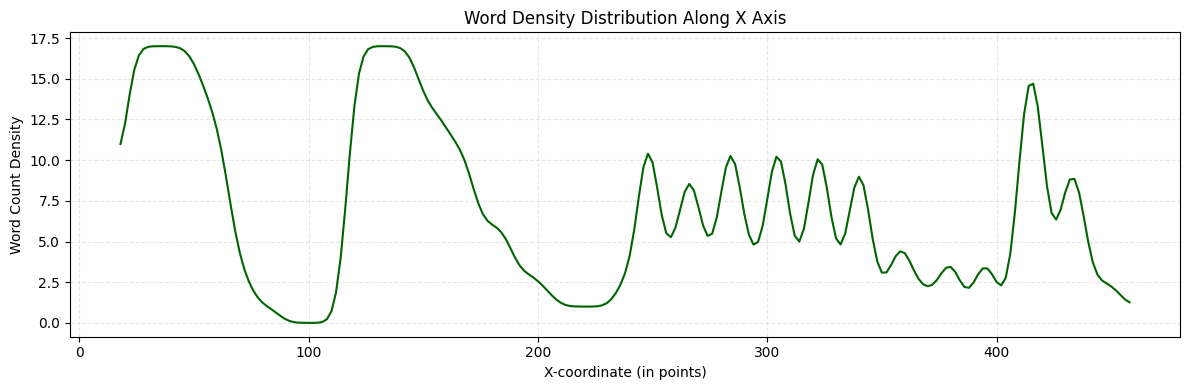

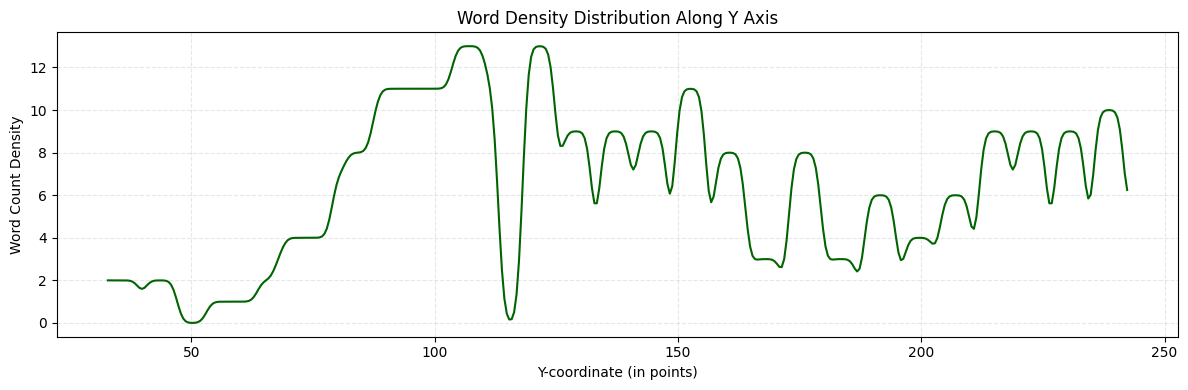

In [161]:
# X-axis density for detecting column separators
x_bins, x_density = compute_density_along_axis(df_sentences, axis='x', bin_size=2, smooth_sigma=2)

# Y-axis density for detecting row separators
y_bins, y_density = compute_density_along_axis(df_sentences, axis='y', bin_size=0.5, smooth_sigma=2)


In [162]:

def find_valleys(smoothed_density, bins, order=10, threshold_ratio=0.3):
    # Compute local minima
    local_minima_idx = argrelextrema(smoothed_density, np.less, order=order)[0]
    
    # Optional: Filter by prominence threshold
    threshold = np.max(smoothed_density) * threshold_ratio
    valleys = [bins[i] for i in local_minima_idx if smoothed_density[i] < threshold]

    return valleys


In [163]:
def find_separators_from_density(smoothed_density, bins, prominence=1.0, distance=5):
    # Invert density to find valleys
    inverted = -smoothed_density

    # Find peaks in the inverted curve (valleys in original)
    peaks, properties = find_peaks(inverted, prominence=prominence, distance=distance)

    # Map peak indices back to bin coordinates
    separators = [bins[i] for i in peaks]
    return separators

In [164]:

def plot_with_separators(df_words, x_separators=None, y_separators=None, figsize=(12, 16)):
    """
    Plots word bounding boxes with column and row separators, with centered text.

    Args:
        df_words (pd.DataFrame): DataFrame containing word bounding box information.
        x_separators (list, optional): List of x-coordinates for vertical separators.
        y_separators (list, optional): List of y-coordinates for horizontal separators.
        figsize (tuple, optional): Figure size. Defaults to (12, 16).
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Coordinate system (PDF-style)
    max_x = df_words['bbox'].apply(lambda b: b[2]).max() + 50
    max_y = df_words['bbox'].apply(lambda b: b[3]).max() + 50

    ax.set_xlim(0, max_x)
    ax.set_ylim(max_y, 0)

    # Draw word boxes
    for _, row in df_words.iterrows():
        x0, y0, x1, y1 = row['bbox']
        width = x1 - x0
        height = y1 - y0
        rect = patches.Rectangle((x0, y0), width, height,
                                 linewidth=0.5, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)
        #  Centering the text:
        ax.text(x0 + width / 2, y0 + height / 2, row['text'], fontsize=8,
                horizontalalignment='center', verticalalignment='center')

    # Draw vertical column separators
    if x_separators:
        for x in x_separators:
            ax.axvline(x, color='red', linestyle='--', linewidth=0.8)

    # Draw horizontal row separators
    if y_separators:
        for y in y_separators:
            ax.axhline(y, color='green', linestyle='--', linewidth=0.8)

    ax.set_title("Bounding Boxes with Column & Row Separators")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


In [165]:
# # Detect more separators (lower threshold and smaller window)
# x_separators = find_valleys(x_density, x_bins, order=10, threshold_ratio=0.5) 
# y_separators = find_valleys(y_density, y_bins, order=10, threshold_ratio=0.5)


In [166]:
x_separators = find_separators_from_density(x_density, x_bins, prominence=1.0, distance=10)
y_separators = find_separators_from_density(y_density, y_bins, prominence=0.7, distance=8)


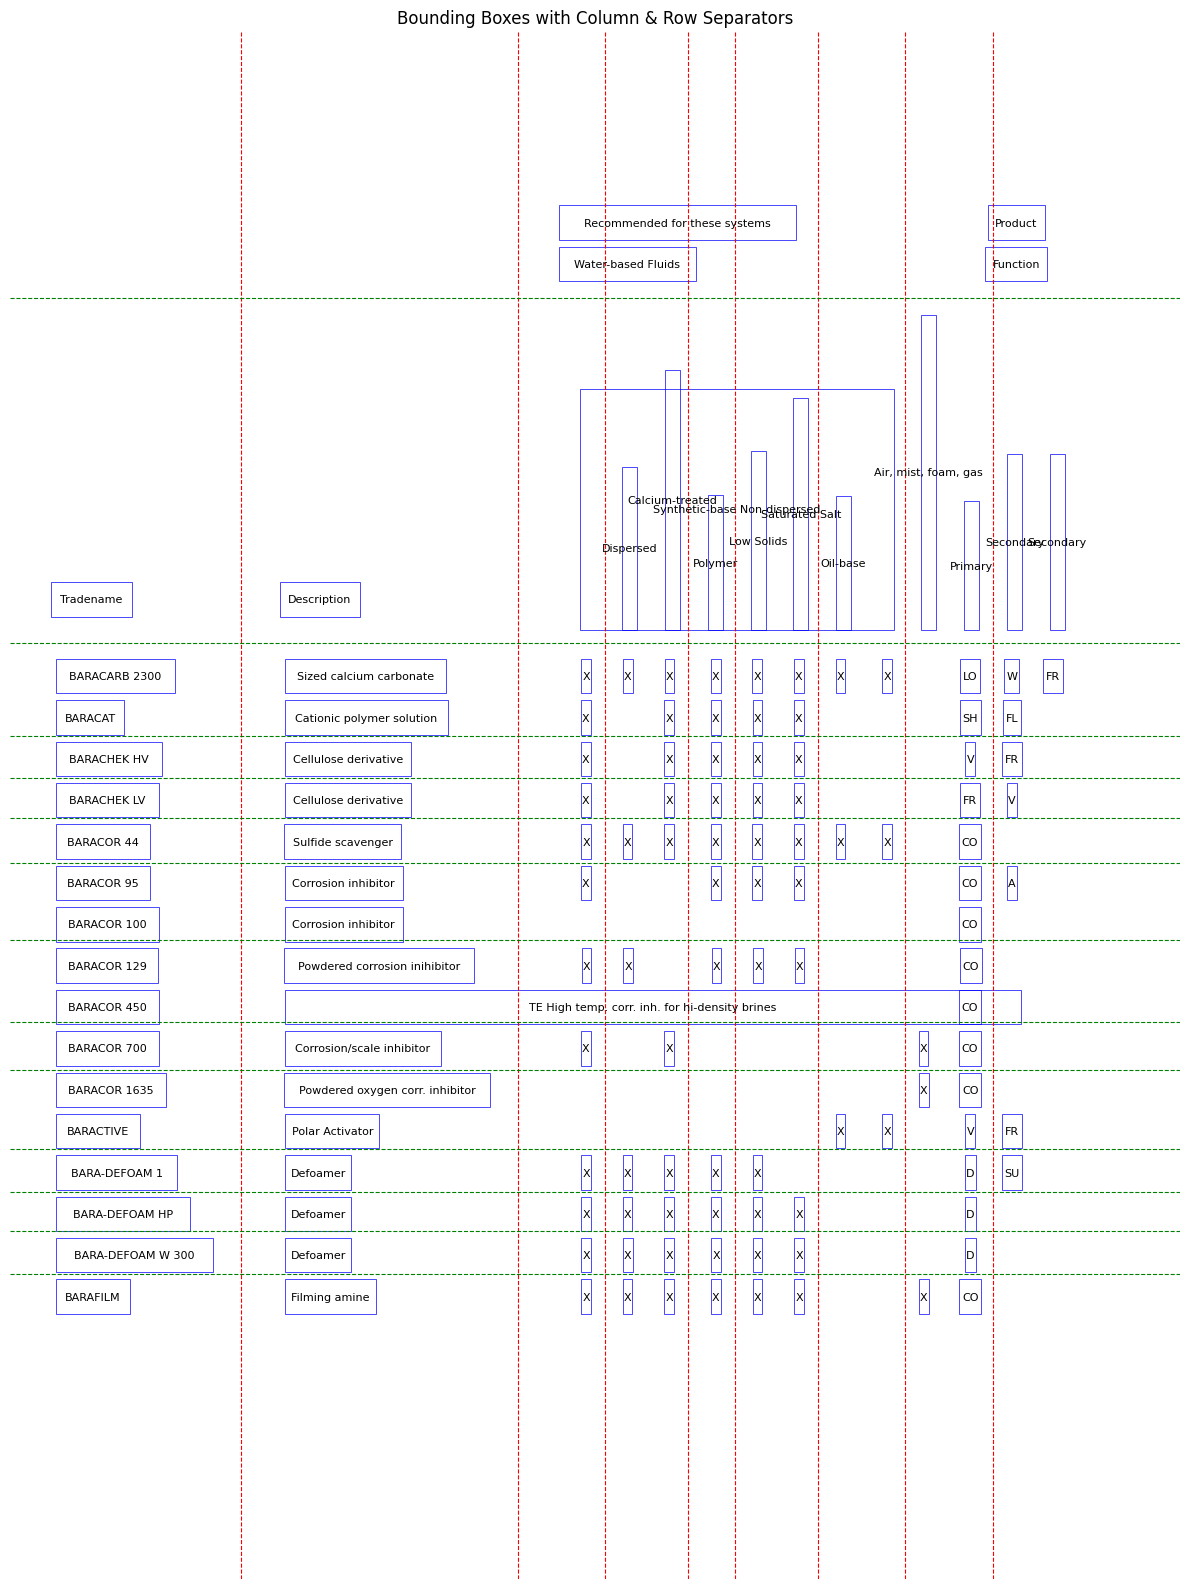

In [167]:
plot_with_separators(df_sentences, x_separators=x_separators, y_separators=y_separators)


### Add Page boundaries

In [168]:
def add_page_boundaries_to_separators(x_separators, y_separators, page_width, page_height, margin=5):
    # Add start and end boundaries for x and y axes
    x_separators = [0 - margin] + x_separators + [page_width + margin]
    y_separators = [0 - margin] + y_separators + [page_height + margin]

    return x_separators, y_separators

In [169]:

# Add the boundaries to your separators
x_separators, y_separators = add_page_boundaries_to_separators(x_separators, y_separators, page_width, page_height)



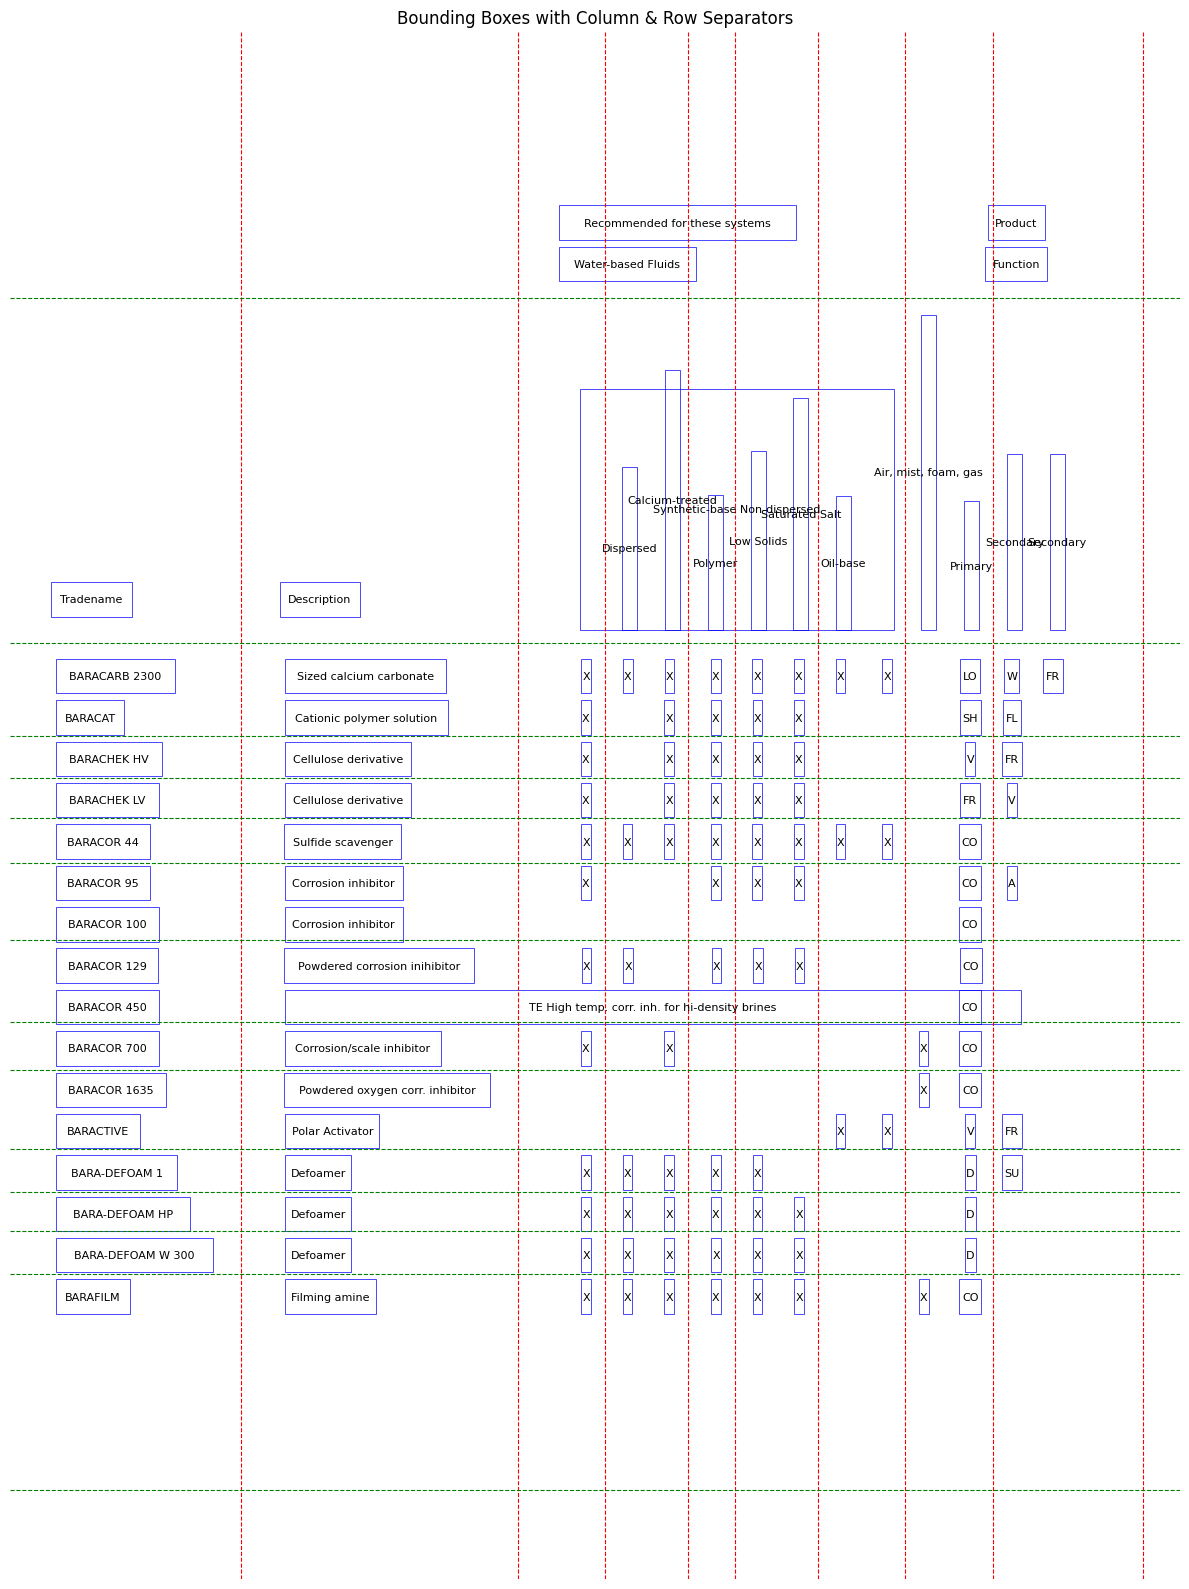

In [171]:
plot_with_separators(df_sentences, x_separators=x_separators, y_separators=y_separators)


### Headers

In [172]:
def identify_axis_headers(df_sentences, x_separators, y_separators):
    column_headers = {}
    row_headers = {}

    # Iterate through each row (bounded by y_separators)
    for i in range(len(y_separators) - 1):
        top = y_separators[i]
        bottom = y_separators[i + 1]
        
        in_row = df_sentences[
            (df_sentences['bbox'].apply(lambda b: b[1]) >= top) &
            (df_sentences['bbox'].apply(lambda b: b[3]) <= bottom)
        ]
        
        if len(in_row) == 1:
            row_headers[i] = in_row.iloc[0]['text']

    # Iterate through each column (bounded by x_separators)
    for j in range(len(x_separators) - 1):
        left = x_separators[j]
        right = x_separators[j + 1]
        
        in_col = df_sentences[
            (df_sentences['bbox'].apply(lambda b: b[0]) >= left) &
            (df_sentences['bbox'].apply(lambda b: b[2]) <= right)
        ]
        
        if len(in_col) == 1:
            column_headers[j] = in_col.iloc[0]['text']

    return row_headers, column_headers


In [173]:
row_headers, column_headers = identify_axis_headers(df_sentences, x_separators, y_separators)

print("Row headers:")
for k, v in row_headers.items():
    print(f"Row {k}: {v}")

print("\nColumn headers:")
for k, v in column_headers.items():
    print(f"Column {k}: {v}")


Row headers:

Column headers:


### Grid Construction

In [174]:
def build_2d_grid_with_sentences(df_sentences, x_separators, y_separators, padding=0.5):
    """
    Build a 2D grid using separators and assign each sentence to one cell,
    with axis-aware boundary adjustment if intersection/touch occurs.

    Returns:
        List of dicts with full metadata + grid_row, grid_col, grid_bbox
    """
    x_separators = sorted(x_separators)
    y_separators = sorted(y_separators)
    results = []

    for _, row in df_sentences.iterrows():
        x0, y0, x1, y1 = row['bbox']

        # === Handle X-Axis (Columns) ===
        col = None
        grid_x0 = grid_x1 = None
        for i in range(len(x_separators) - 1):
            left = x_separators[i]
            right = x_separators[i + 1]

            # If sentence bbox intersects or touches either edge — skip
            intersects = (
                abs(x0 - left) <= padding or abs(x1 - right) <= padding or
                (x0 < right and x1 > left and (x0 <= left or x1 >= right))
            )
            if intersects:
                continue

            if x0 >= left and x1 <= right:
                col = i
                grid_x0 = left
                grid_x1 = right
                break

        # If intersected and no valid found, fallback: use last valid
        if col is None:
            for i in range(len(x_separators) - 2):
                left = x_separators[i]
                right = x_separators[i + 2]
                if x0 >= left and x1 <= right:
                    col = i
                    grid_x0 = left
                    grid_x1 = right
                    break

        # === Handle Y-Axis (Rows) ===
        row_idx = None
        grid_y0 = grid_y1 = None
        for j in range(len(y_separators) - 1):
            top = y_separators[j]
            bottom = y_separators[j + 1]

            intersects = (
                abs(y0 - top) <= padding or abs(y1 - bottom) <= padding or
                (y0 < bottom and y1 > top and (y0 <= top or y1 >= bottom))
            )
            if intersects:
                continue

            if y0 >= top and y1 <= bottom:
                row_idx = j
                grid_y0 = top
                grid_y1 = bottom
                break

        # Fallback (rare)
        if row_idx is None:
            for j in range(len(y_separators) - 2):
                top = y_separators[j]
                bottom = y_separators[j + 2]
                if y0 >= top and y1 <= bottom:
                    row_idx = j
                    grid_y0 = top
                    grid_y1 = bottom
                    break

        # Record the result
        results.append({
            **row.to_dict(),
            "grid_row": row_idx,
            "grid_col": col,
            "grid_bbox": (grid_x0, grid_y0, grid_x1, grid_y1)
        })

    return pd.DataFrame(results)


In [175]:
df_grid = build_2d_grid_with_sentences(df_sentences, x_separators, y_separators)

df_grid.head(10)


,text,font_size,font_name,is_bold,bbox,y_position,grid_row,grid_col,grid_bbox
0,Recommended for these systems,6.5,Arial.Bold054.188,True,"(237.88002014160156, 32.81417465209961, 340.57...",32.814175,0,NaN,"(None, -5, None, 50.31417465209961)"
1,Product,6.5,Arial.Bold054.188,True,"(423.601318359375, 32.81417465209961, 448.1440...",32.814175,0,7.0,"(387.8930206298828, -5, 491.0, 50.31417465209961)"
2,Water-based Fluids,6.5,Arial.Bold054.188,True,"(237.88002014160156, 40.61417770385742, 297.01...",40.614178,0,NaN,"(None, -5, None, 50.31417465209961)"
3,Function,6.5,Arial.Bold054.188,True,"(422.55999755859375, 40.61417770385742, 449.22...",40.614178,0,7.0,"(387.8930206298828, -5, 491.0, 50.31417465209961)"
4,"Air, mist, foam, gas",6.5,Arial.Bold054.188,True,"(394.7665710449219, 53.430419921875, 401.26657...",53.430420,1,7.0,"(387.8930206298828, 50.31417465209961, 425.893..."
5,Calcium-treated,6.5,Arial.Bold054.188,True,"(283.7664489746094, 63.908504486083984, 290.26...",63.908504,1,3.0,"(257.8930206298828, 50.31417465209961, 293.893..."
6,Synthetic-base Non-dispersed,6.5,Arial.Bold054.188,True,"(246.80625915527344, 67.388916015625, 382.7864...",67.388916,1,NaN,"(None, 50.31417465209961, None, 115.3141746520..."
7,Saturated Salt,6.5,Arial.Bold054.188,True,"(339.3262634277344, 69.1896743774414, 345.8262...",69.189674,1,5.0,"(313.8930206298828, 50.31417465209961, 349.893..."
8,Low Solids,6.5,Arial.Bold054.188,True,"(320.8461608886719, 79.17784118652344, 327.346...",79.177841,1,5.0,"(313.8930206298828, 50.31417465209961, 349.893..."
9,Secondary,6.5,Arial.Bold054.188,True,"(431.8462829589844, 79.76471710205078, 438.346...",79.764717,1,8.0,"(425.8930206298828, 50.31417465209961, 491.0, ..."


In [176]:
def visualize_grid_assignments(df_grid, x_separators, y_separators, figsize=(14, 16)):
    fig, ax = plt.subplots(figsize=figsize)

    # Set axis limits
    max_x = max(x_separators) + 50
    max_y = max(y_separators) + 50
    ax.set_xlim(0, max_x)
    ax.set_ylim(max_y, 0)

    # Draw grid cells
    for i in range(len(x_separators) - 1):
        for j in range(len(y_separators) - 1):
            x0 = x_separators[i]
            x1 = x_separators[i + 1]
            y0 = y_separators[j]
            y1 = y_separators[j + 1]

            rect = patches.Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                linewidth=0.5,
                edgecolor='gray',
                facecolor='lightgray',
                alpha=0.1
            )
            ax.add_patch(rect)
            # Optional: label cell (row, col)
            ax.text(x0 + 2, y0 + 8, f'({j}, {i})', fontsize=6, color='gray')

    # Draw sentence boxes and annotate
    for _, row in df_grid.iterrows():
        x0, y0, x1, y1 = row['bbox']
        width = x1 - x0
        height = y1 - y0

        rect = patches.Rectangle((x0, y0), width, height,
                                 linewidth=1, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)

        # Center the text within the box
        ax.text(x0 + width / 2, y0 + height / 2, row['text'],
                fontsize=7, ha='center', va='center')

    # Draw separators
    for x in x_separators:
        ax.axvline(x, color='red', linestyle='--', linewidth=0.8)
    for y in y_separators:
        ax.axhline(y, color='green', linestyle='--', linewidth=0.8)

    ax.set_title("Sentence Bounding Boxes within Grid Cells")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


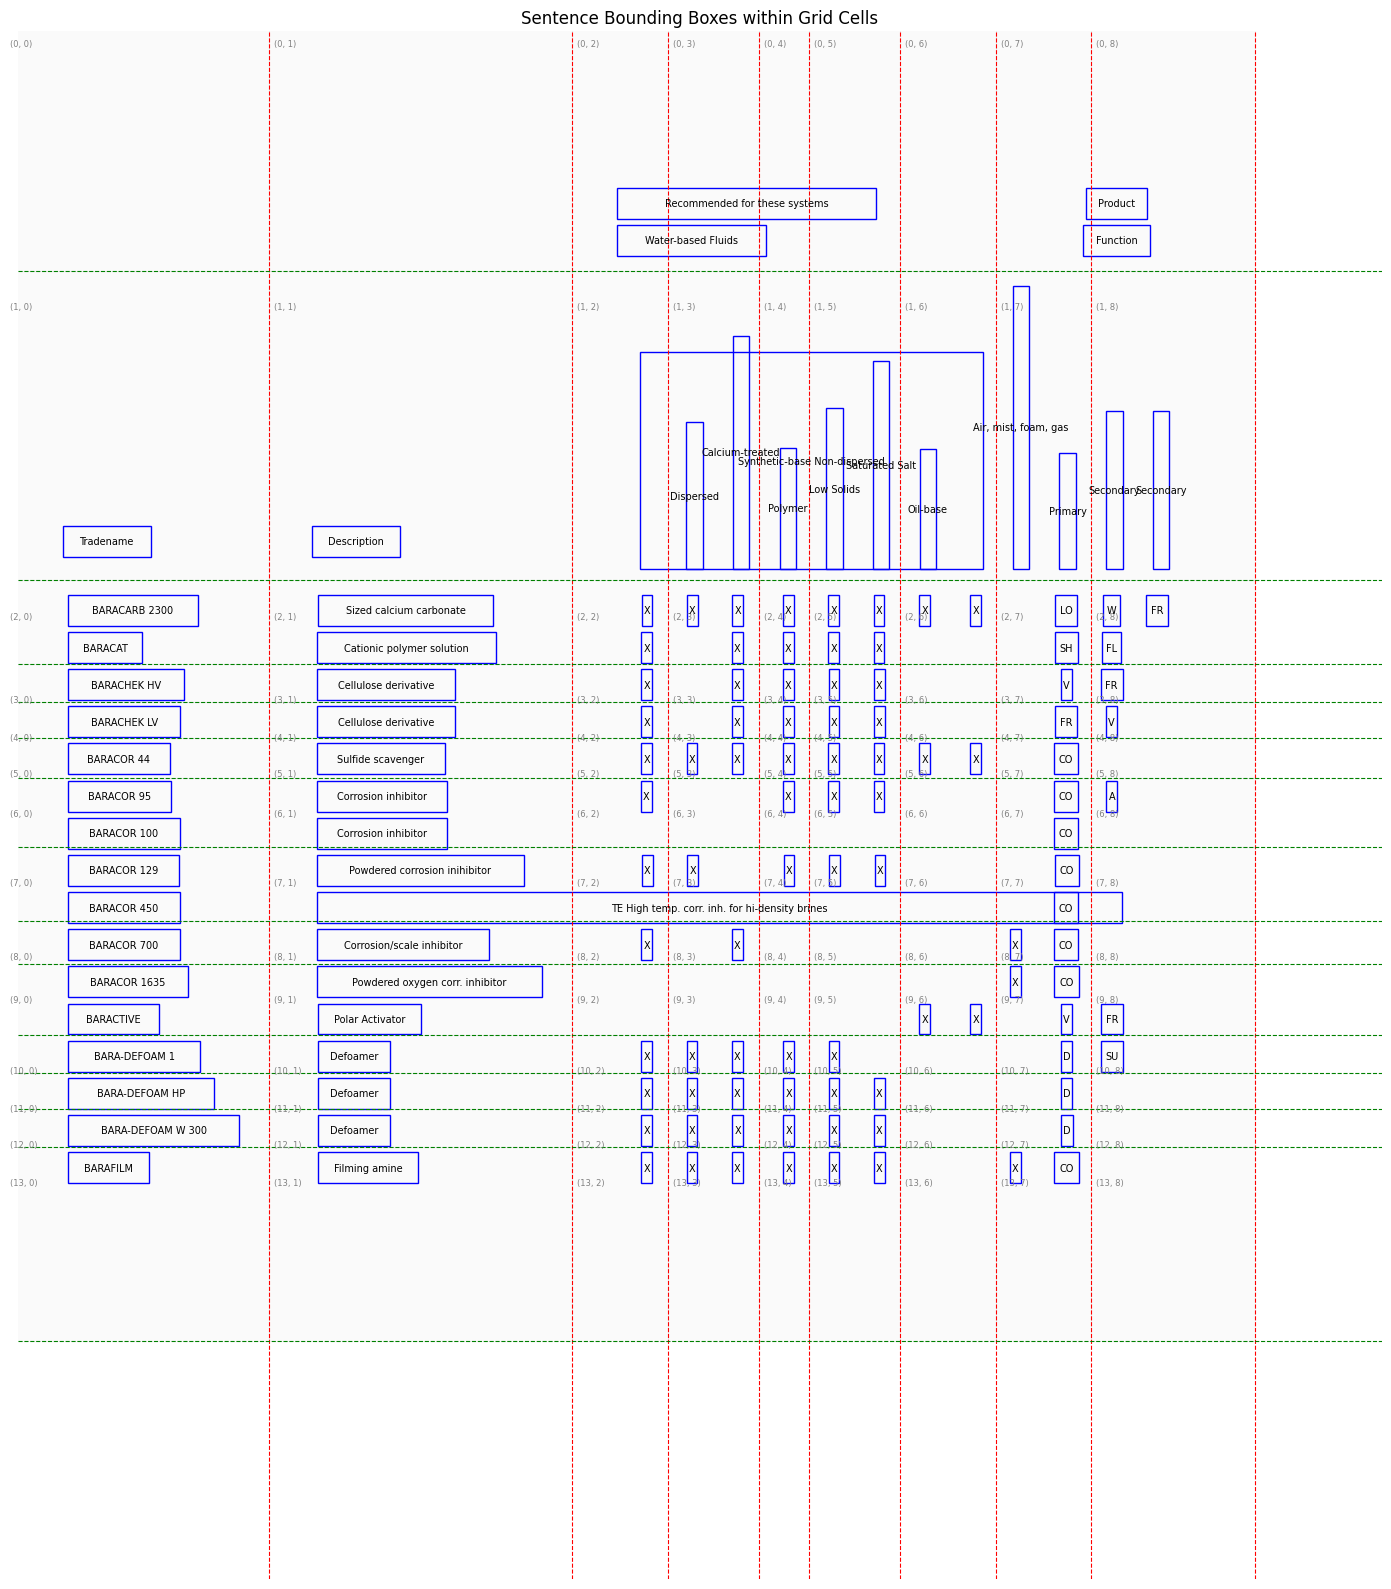

In [177]:
visualize_grid_assignments(df_grid, x_separators, y_separators)


#### Header

In [178]:
def build_separator_grid(x_separators, y_separators):
    """
    Constructs a grid of bounding boxes using x and y separators.
    Returns a list of grid cell definitions as (row_idx, col_idx, bbox).
    """
    grid_cells = []
    for row_idx in range(len(y_separators) - 1):
        for col_idx in range(len(x_separators) - 1):
            x0 = x_separators[col_idx]
            x1 = x_separators[col_idx + 1]
            y0 = y_separators[row_idx]
            y1 = y_separators[row_idx + 1]
            bbox = (x0, y0, x1, y1)
            grid_cells.append({
                "row": row_idx,
                "col": col_idx,
                "bbox": bbox
            })
    return grid_cells

def assign_sentences_to_grid(df_sentences, grid_cells):
    """
    For each sentence in df_sentences, assign it to a grid cell
    based on the centroid of its bbox.
    """
    grid_map = {}

    for _, row in df_sentences.iterrows():
        x0, y0, x1, y1 = row['bbox']
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2  # Centroid

        for cell in grid_cells:
            bx0, by0, bx1, by1 = cell['bbox']
            if bx0 <= cx <= bx1 and by0 <= cy <= by1:
                key = (cell['row'], cell['col'])
                entry = {
                    "text": row['text'],
                    "font_size": row['font_size'],
                    "font_name": row['font_name'],
                    "is_bold": row['is_bold'],
                    "bbox": row['bbox'],
                    "y_position": row['y_position'],
                    "centroid": (cx, cy)
                }
                grid_map.setdefault(key, []).append(entry)
                break  # Move to next sentence after first match

    return grid_map


In [179]:
# Step 1: Build structural grid using separators
grid_cells = build_separator_grid(x_separators, y_separators)

# Step 2: Assign sentences to their respective grid cells
grid_map = assign_sentences_to_grid(df_sentences, grid_cells)


In [180]:
def visualize_grids(df_sentences, grid_cells, grid_map):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    max_x = max([cell["bbox"][2] for cell in grid_cells]) + 20
    max_y = max([cell["bbox"][3] for cell in grid_cells]) + 20
    ax.set_xlim(0, max_x)
    ax.set_ylim(max_y, 0)
    
    # Draw separator grid
    for cell in grid_cells:
        x0, y0, x1, y1 = cell["bbox"]
        rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                 linewidth=1, edgecolor='gray', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(x0 + 5, y0 + 15, f"{cell['row']},{cell['col']}", fontsize=7, color='gray')

    # Draw content bounding boxes
    for _, row in df_sentences.iterrows():
        x0, y0, x1, y1 = row["bbox"]
        rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                 linewidth=1, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)
        cx = (x0 + x1) / 2
        cy = (y0 + y1) / 2
        ax.text(cx, cy, row["text"], fontsize=8, ha='center', va='center', color='blue')

    ax.set_title("Overlay: Grid Cells and Word Bounding Boxes")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


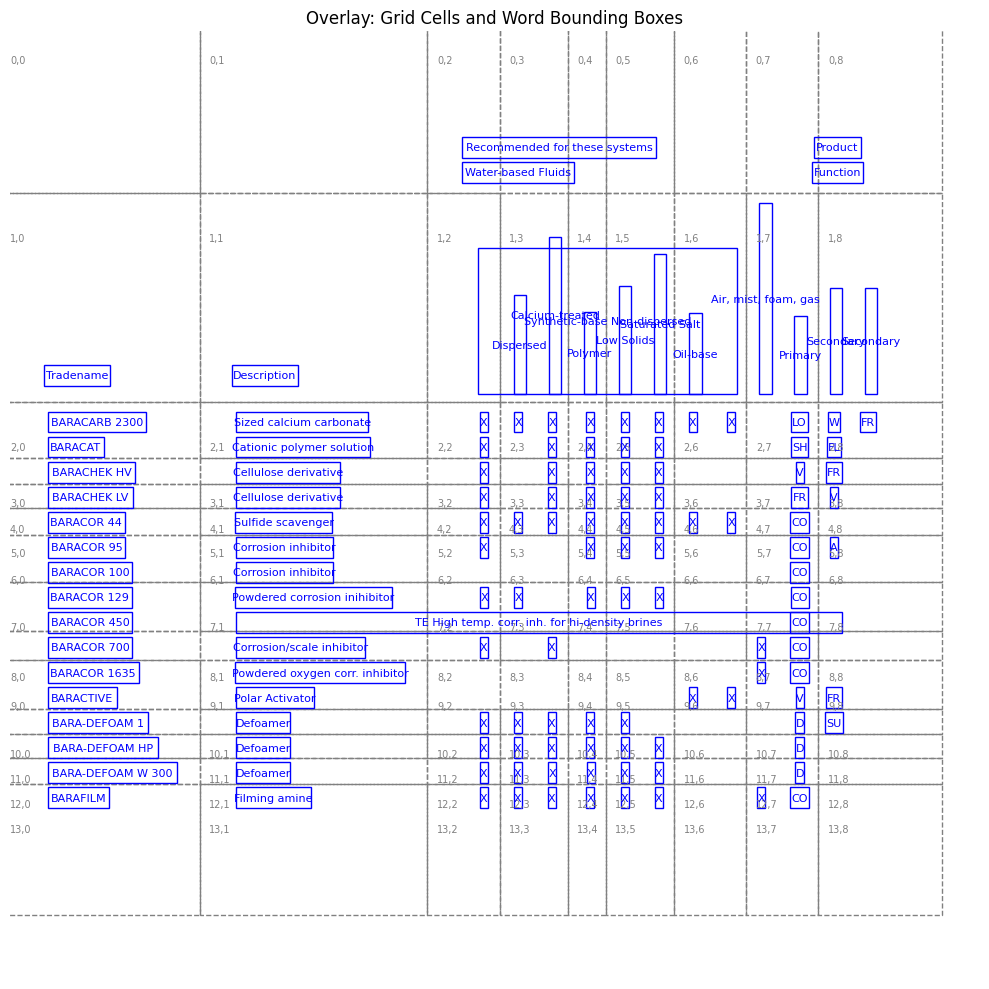

In [181]:
visualize_grids(df_sentences, grid_cells, grid_map)


### Extract the lines from the pdf

#### Method 1

In [15]:
def extract_lines_from_image(pdf_path, dpi=300, page_num=0):
    # 1. Convert PDF to grayscale image
    images = convert_from_path(pdf_path, dpi=dpi)
    image = np.array(images[page_num].convert('L'))

    # 2. Binarize the image
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. Edge detection
    edges = cv2.Canny(binary, 50, 150, apertureSize=3)

    # 4. Use Hough Line Transform
    lines_p = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=300,
        minLineLength=100,
        maxLineGap=5
    )

    # 5. Parse and collect lines
    hough_lines = []
    if lines_p is not None:
        for line in lines_p:
            x1, y1, x2, y2 = line[0]
            hough_lines.append(((x1, y1), (x2, y2)))

    return hough_lines, image, edges


In [16]:
def visualize_lines_on_image(image, lines):

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image, cmap='gray')

    for (x1, y1), (x2, y2) in lines:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    ax.set_title("Extracted Line Boxes")
    plt.axis('off')
    plt.show()


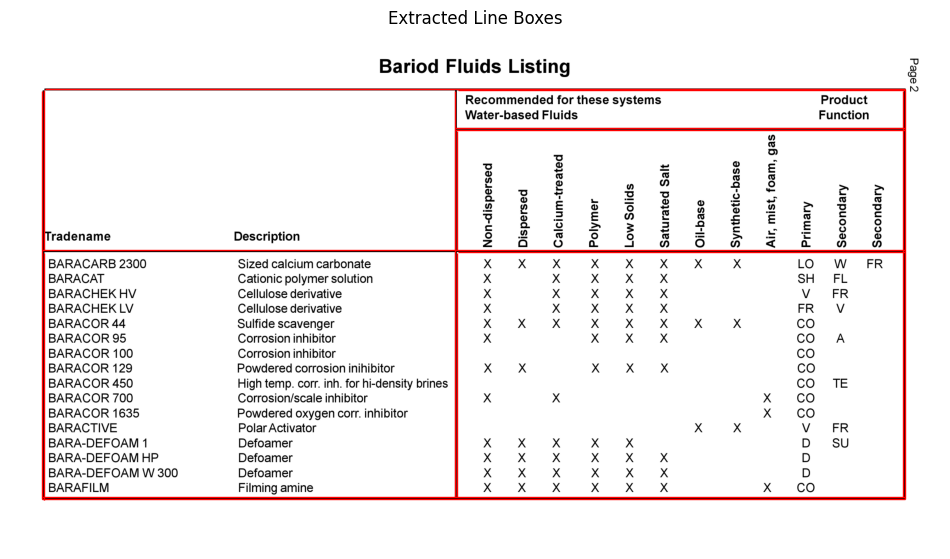

In [17]:
lines, image, lines_mask = extract_lines_from_image(test_sample_2, dpi=300, page_num=0)

visualize_lines_on_image(image, lines)



#### Method 2

In [36]:

def render_page_to_image(page, zoom=2):
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    if pix.n == 4:  # remove alpha
        img = img[:, :, :3]
    return img

In [42]:
def extract_lines_from_image(image, min_line_length=100, max_line_gap=5):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180,
                            threshold=300, minLineLength=min_line_length, maxLineGap=max_line_gap)

    horizontal = []
    vertical = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if abs(y2 - y1) < 5:  # horizontal
                y = (y1 + y2) // 2
                horizontal.append(y)
            elif abs(x2 - x1) < 5:  # vertical
                x = (x1 + x2) // 2
                vertical.append(x)

    return sorted(set(horizontal)), sorted(set(vertical))


In [43]:
def merge_separators(inferred_separators, hough_separators, tolerance=5):
    merged = list(inferred_separators)
    for s in hough_separators:
        if not any(abs(s - i) <= tolerance for i in merged):
            merged.append(s)
    return sorted(merged)


In [44]:
# Step 1: Render
img = render_page_to_image(page)

# Step 2: Detect lines
y_hough, x_hough = extract_lines_from_image(img)

# Step 3: Merge
x_final = merge_separators(x_separators, x_hough)
y_final = merge_separators(y_separators, y_hough)


In [45]:
def visualize_detected_lines(image, x_lines, y_lines):
    img_copy = image.copy()
    for x in x_lines:
        cv2.line(img_copy, (x, 0), (x, image.shape[0]), (0, 0, 255), 1)
    for y in y_lines:
        cv2.line(img_copy, (0, y), (image.shape[1], y), (0, 255, 0), 1)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_copy)
    plt.axis('off')
    plt.title("Detected Lines (Red = vertical, Green = horizontal)")
    plt.show()


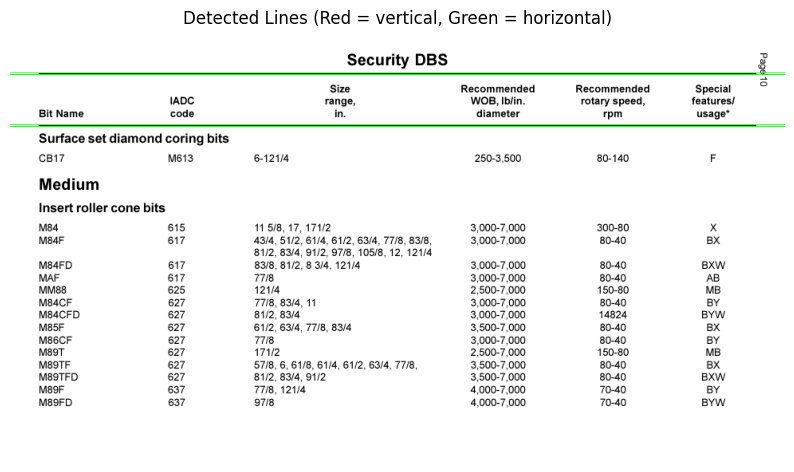

In [46]:
visualize_detected_lines(img, x_hough, y_hough)

### Reconstruction

In [182]:
def reconstruct_table(df_words, x_separators, y_separators):
    table = []

    for i in range(len(y_separators) - 1):
        row = []
        y0, y1 = y_separators[i], y_separators[i + 1]

        for j in range(len(x_separators) - 1):
            x0, x1 = x_separators[j], x_separators[j + 1]

            # Get words that fall inside this cell's bounding box
            in_cell = df_words[
                df_words["bbox"].apply(lambda b: x0 <= b[0] <= x1 and y0 <= b[1] <= y1)
            ]

            if not in_cell.empty:
                # Compute x-position (left edge) to sort words horizontally
                in_cell = in_cell.copy()
                in_cell["x_pos"] = in_cell["bbox"].apply(lambda b: b[0])
                in_cell = in_cell.sort_values(by="x_pos")

                # Construct the text content, applying bold formatting
                cell_words = []
                for _, word in in_cell.iterrows():
                    txt = word["text"]
                    if word["is_bold"]:
                        txt = f"**{txt}**"  # Markdown bold
                    cell_words.append(txt)

                cell_text = " ".join(cell_words)
            else:
                cell_text = ""

            row.append(cell_text)
        table.append(row)

    return table


In [183]:

reconstructed = reconstruct_table(df_grid, x_separators, y_separators)

print(tabulate(reconstructed, headers="firstrow", tablefmt="grid"))

+-------------------------+------------------------------------------------------------------------------+------------------------------------------------------------+-----------------------------------+-------------+-----------------------------------+--------------+--------------------------------------+-----------------------------+
|                         |                                                                              | **Recommended for these systems** **Water-based Fluids**   |                                   |             |                                   |              | **Function** **Product**             |                             |
+=========================+==============================================================================+============================================================+===================================+=============+===================================+==============+======================================+=================

In [184]:

reconstructed = reconstruct_table(df_sentences, x_separators, y_separators)

print(tabulate(reconstructed, headers="firstrow", tablefmt="grid"))

+-------------------------+------------------------------------------------------------------------------+------------------------------------------------------------+-----------------------------------+-------------+-----------------------------------+--------------+--------------------------------------+-----------------------------+
|                         |                                                                              | **Recommended for these systems** **Water-based Fluids**   |                                   |             |                                   |              | **Function** **Product**             |                             |
+=========================+==============================================================================+============================================================+===================================+=============+===================================+==============+======================================+=================

In [185]:
df_table = pd.DataFrame(reconstructed[1:], columns=reconstructed[0])

df_table

,,,**Recommended for these systems** **Water-based Fluids**,,,,,**Function** **Product**,
0,**Tradename**,**Description**,**Synthetic-base Non-dispersed**,**Dispersed** **Calcium-treated**,**Polymer**,**Low Solids** **Saturated Salt**,**Oil-base**,"**Air, mist, foam, gas** **Primary**",**Secondary** **Secondary**
1,BARACARB 2300 BARACAT,Cationic polymer solution Sized calcium carbonate,X X,X X X,X X,X X X X,X X,SH LO,FL W FR
2,BARACHEK HV,Cellulose derivative,X,X,X,X X,,V,FR
3,BARACHEK LV,Cellulose derivative,X,X,X,X X,,FR,V
4,BARACOR 44,Sulfide scavenger,X,X X,X,X X,X X,CO,
5,BARACOR 95 BARACOR 100,Corrosion inhibitor Corrosion inhibitor,X,,X,X X,,CO CO,A
6,BARACOR 129 BARACOR 450,Powdered corrosion inihibitor TE High temp. co...,X,X,X,X X,,CO CO,
7,BARACOR 700,Corrosion/scale inhibitor,X,X,,,,X CO,
8,BARACOR 1635 BARACTIVE,Powdered oxygen corr. inhibitor Polar Activator,,,,,X X,X CO V,FR
9,BARA-DEFOAM 1,Defoamer,X,X X,X,X,,D,SU
